In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

import genbart as gb

In [2]:
conf_color = '#227018'
fill_color = '#44f02e'

plt.style.use("bart_style.mplstyle")

#  One Dimensional Example

In [15]:
def example_f(x: np.array):
    return np.sin(2*x) + np.cos(5*x) + 0.2*(x - 5.0)**2

In [16]:
m = [10, 100, 200]
n_samples = 300
x = np.linspace(1e-16, 10, n_samples)
y = example_f(x)
y_noise = example_f(x) + 0.5*np.random.randn(n_samples)

In [17]:
model_10 = gb.RegBart(m=10, n_burn=200, n_samples=1000).fit(x, y_noise)

In [ ]:
model_100 = gb.RegBart(m=100, n_burn=200, n_samples=500).fit(x, y_noise)

In [ ]:
model_200 = gb.RegBart(m=200, n_burn=200, n_samples=500).fit(x, y_noise)

In [18]:
pred_x = np.linspace(2e-16, 10, 200)
pred_y = example_f(pred_x)
y_bart = []

y_bart.append(model_10.predict(pred_x))
y_bart.append(model_100.predict(pred_x))
y_bart.append(model_200.predict(pred_x))

NameError: name 'model_100' is not defined

In [ ]:
mse = []
cov_probs = []
for i in range(1):
    mse.append(np.mean((pred_y - y_bart[i]["prediction"])**2))
    cov_probs.append(np.mean([(y_bart[i]["conf_int_low"][j] < pred_y[j] < y_bart[i]["conf_int_high"][j]) for j in range(200)]))

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharey=True, dpi=200)
for i in range(len(y_bart)):
    axes[i].plot(x, y, label=r"$f(x)$")
    axes[i].plot(pred_x, y_bart[i]["prediction"], label="Mean prediction", zorder=10)
    axes[i].plot(pred_x, y_bart[i]["conf_int_low"], ls='--', lw=1.1,  c=conf_color, label="90% conf. interval")
    axes[i].plot(pred_x, y_bart[i]["conf_int_high"], ls='--', lw=1.1, c=conf_color)
    axes[i].fill_between(pred_x, y_bart[i]["conf_int_low"], y_bart[i]["conf_int_high"], color=fill_color, alpha=0.3)
    axes[i].set_title(f"m = {m[i]}", fontsize=9)
    axes[i].text(0.655, 0.09,
                 f"MSE = {mse[i]:.3f}\nP_cov = {cov_probs[i]:.2f}",
                 transform=axes[i].transAxes,
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"))
    
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=3)

fig.suptitle("Approximating $f$ with BART", fontsize=12)

plt.subplots_adjust(bottom=0.12)
plt.subplots_adjust(top=0.87)
plt.show()

# Multidimensional Example

In [ ]:
def example_2d_f(x, y):
    return np.sin(0.05*x*y) + 0.3*(np.cos(x) + np.cos(y)) - 0.05*x*y

In [ ]:
x = np.linspace(-2*np.pi, 2*np.pi, 100)
y = np.linspace(-2*np.pi, 2*np.pi, 100)
X, Y = np.meshgrid(x, y)

true_Z = example_2d_f(X, Y)
Z = true_Z + 0.25*np.random.randn(len(x), len(y))


In [ ]:
model_2d = gb.bart(m=100).fit(np.column_stack((X.ravel(), Y.ravel())), Z.ravel())

In [ ]:
x_pred = np.linspace(-2*np.pi, 2*np.pi, 20)
X_pred, Y_pred = np.meshgrid(x_pred, x_pred)
pred_points = np.column_stack((X_pred.ravel(), Y_pred.ravel()))
preds_2d = model_2d.predict(pred_points)

slice_mask = np.isclose(Y.ravel(), min(y))
preds_slice = model_2d.predict(np.column_stack((X.ravel(), Y.ravel()))[slice_mask, :])

In [ ]:
fig = plt.figure(figsize=(8, 7), dpi=200)
gs = fig.add_gridspec(2, 2)

ax_original = fig.add_subplot(gs[0, 0], projection="3d")
ax_original.plot_surface(X, Y, true_Z)
ax_original.set_title("Orginal function")
ax_original.set_xlabel("")
ax_original.text2D(0.3, 0.09, "x", transform=ax_original.transAxes)
ax_original.set_xticklabels([])
ax_original.set_ylabel("")
ax_original.text2D(0.82, 0.17, "y", transform=ax_original.transAxes)
ax_original.set_yticklabels([])
ax_original.set_zlabel("")
ax_original.text2D(0.97, 0.55, "z", transform=ax_original.transAxes)
ax_original.set_zticklabels([])

ax_bart = fig.add_subplot(gs[0, 1], projection="3d")
ax_bart.plot_trisurf(X_pred.ravel(), Y_pred.ravel(), preds_2d["prediction"])
ax_bart.set_title("BART approximation")
ax_bart.set_xlabel("")
ax_bart.text2D(0.3, 0.09, "x", transform=ax_bart.transAxes)
ax_bart.set_xticklabels([])
ax_bart.set_ylabel("")
ax_bart.text2D(0.82, 0.17, "y", transform=ax_bart.transAxes)
ax_bart.set_yticklabels([])
ax_bart.set_zlabel("")
ax_bart.text2D(0.97, 0.55, "z", transform=ax_bart.transAxes)
ax_bart.set_zticklabels([])

ax_slice = fig.add_subplot(gs[1, :])
ax_slice.plot(x, example_2d_f(x, min(y)), label=r"f(x, $-2\pi$)")
ax_slice.plot(x, preds_slice["prediction"], label="Mean prediction")
ax_slice.plot(x, preds_slice["conf_int_low"], ls='--', lw=1.1,  c=conf_color, label="90% conf. interval")
ax_slice.plot(x, preds_slice["conf_int_high"], ls='--', lw=1.1, c=conf_color)
ax_slice.fill_between(x, preds_slice["conf_int_low"], preds_slice["conf_int_high"], color=fill_color, alpha=0.3)
ax_slice.set_title(r"BART approximation for $y=-2\pi$ fixed")
ax_slice.legend()

plt.show()

# Friedman Function Example

In [ ]:
def friedman(x: np.ndarray):
    return (10.0 * np.sin(np.pi*x[:, 0]*x[:, 1])
            + 20.0 * (x[:, 2]-0.5)**2
            + 10.0 * x[:, 3]
            + 5.0 * x[:, 4])

## Variable selection

In [ ]:
n_samples = 500
x = np.random.rand(n_samples, 50)
true_y = friedman(x)
y = true_y + 0.5*np.random.randn(n_samples)

vs_model10 = gb.RegBart(m=10, n_burn=200, n_samples=5000).fit(x, y)

In [ ]:
vs_model20 = gb.bart(m=20, n_burn=200, n_samples=5000).fit(x, y)

In [ ]:
vs_model50 = gb.bart(m=50, n_burn=200, n_samples=5000).fit(x, y)

In [ ]:
variable_importance_10 = vs_model10.variable_importance()
variable_importance_20 = vs_model20.variable_importance()
variable_importance_50 = vs_model50.variable_importance()

In [ ]:
fig, ax = plt.subplots(figsize=(4,3), dpi=150)

ax.plot(variable_importance_10, marker='^', label="m=10")
ax.plot(variable_importance_20, marker='^', label="m=20")
ax.plot(variable_importance_50, marker='^', label="m=50")

ax.set_ylim(0.0, 0.06)
ax.set_title("Inferred variable importance")
ax.set_xlabel("Variable")
ax.set_ylabel("Variable importance")

plt.legend()
plt.show()

## Marginalizations

In [19]:
n_samples = 100
x = np.random.rand(n_samples, 2)
true_y = x[:, 0] + x[:, 1]**2
y = true_y + 0.5*np.random.randn(n_samples)

In [21]:
model_marg = gb.RegBart(m=200, n_samples=500).fit(x, y)

In [22]:
marg_x1 = model_marg.marginalize(0, np.linspace(0, 1, 10))

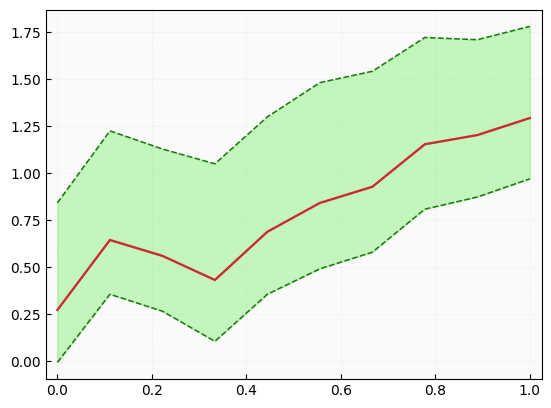

In [25]:
plt.plot(np.linspace(0, 1, 10), marg_x1["prediction"])
plt.plot(np.linspace(0, 1, 10), marg_x1["conf_int_low"], ls='--', lw=1.1,  c=conf_color, label="90% conf. interval")
plt.plot(np.linspace(0, 1, 10), marg_x1["conf_int_high"], ls='--', lw=1.1, c=conf_color)
plt.fill_between(np.linspace(0, 1, 10), marg_x1["conf_int_low"], marg_x1["conf_int_high"], color=fill_color, alpha=0.3)
plt.show()